In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("data set e libs carregadas!")

data set e libs carregadas!


In [158]:
cali = fetch_california_housing(as_frame=True)
cali.target

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [159]:
df = cali.frame

In [160]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [161]:
df.shape

(20640, 9)

In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [163]:
x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
df["MedHouseVal"]

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [164]:
print(x.shape)

(20640, 8)


In [165]:

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.15,
    random_state=20
)

print(x_train.shape)
print(x_test.shape)

(17544, 8)
(3096, 8)


In [166]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=20
)

In [167]:
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred[:10]

array([1.58515  , 2.34841  , 1.39334  , 2.27404  , 2.0835   , 1.55615  ,
       1.2142   , 1.47818  , 3.0333902, 2.0357001])

In [168]:
y_test[:10]

6111     1.176
17742    2.922
79       1.313
13150    2.659
527      2.102
3147     1.629
13458    1.012
6934     1.141
8692     2.554
17323    2.598
Name: MedHouseVal, dtype: float64

In [169]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

MAE: 0.32714785174418626
MSE: 0.2562486764786925
R²: 0.81246457237571


In [170]:
resultado = pd.DataFrame({
    "Real": y_test[:10].values,
    "Previsto": y_pred[:10]
})

resultado

,Real,Previsto
0,1.176,1.58515
1,2.922,2.34841
2,1.313,1.39334
3,2.659,2.27404
4,2.102,2.08350
5,1.629,1.55615
6,1.012,1.21420
7,1.141,1.47818
8,2.554,3.03339
9,2.598,2.03570


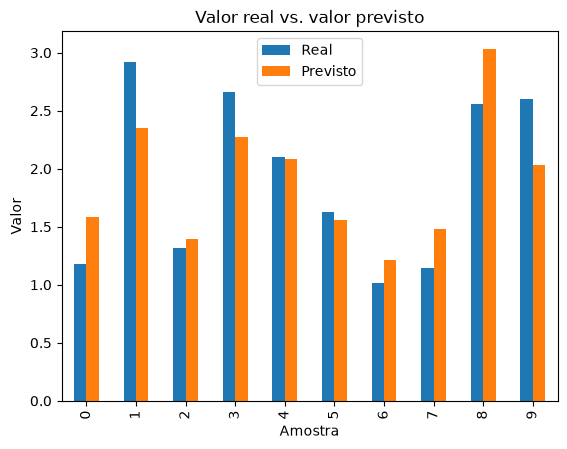

In [171]:
resultado[["Real", "Previsto"]].plot(
    kind="bar"
)

plt.title("Valor real vs. valor previsto")
plt.xlabel("Amostra")
plt.ylabel("Valor")
plt.show()

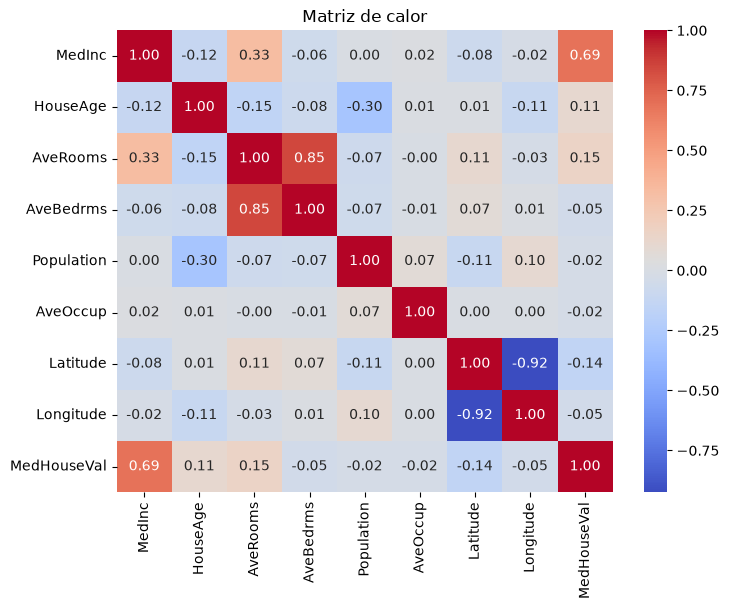

In [172]:
matriz = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    matriz,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de calor")
plt.show()